In [15]:
import numpy as np
import matplotlib.pyplot as plt


In [16]:
x_values = np.array(np.linspace(-0.75,0.75,6))
y_values = np.tan(x_values)

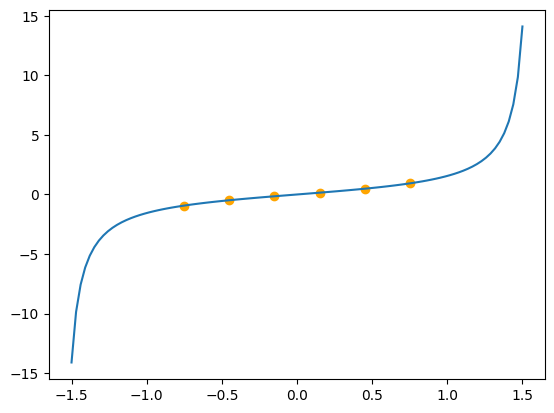

In [17]:
plt.plot(np.linspace(-1.5,1.5,100), np.tan(np.linspace(-1.5,1.5,100)))
plt.scatter(x_values, y_values, color='orange')

In [18]:
a = -0.75
b = 0.75



In [19]:
def numerical_derivative(f, x0, h):
    """Вычисляет f'(x0) по трёхточечной формуле."""
    x1 = x0 + h
    x2 = x0 + 2*h
    return (-3*f(x0) + 4*f(x1) - f(x2)) / (2*h)
#С помощью этой штуки можно приближенно вычислить производную в точке x_0 для tan(x), однако мне лень, по условию она у нас дана 

In [20]:
'''
Мы решаем задачку квадратичного сплайна, изначально нам дано x0,x1,x2 ....
Дано значение функции в этих узлах f(x0), f(x1), f(x2) и тд
И дана производная в точке f'(x0). 
На паре мы получали рекурентную формулу
S_j+1 = f[x_j, x_j+1] - f[x_j-1, x_j] - S_j
Мы стартуем с точки a=x0 => f(x0). S1 = f[x0,x1] - f'(x0)
Соответствуенно так находим S2, S3 и тд.
'''

df_x0 = 1 / (np.cos(x_values[0])**2) # tan(-1.5)' - производная функции tan в точке -1.5
df_x0

1.8678719641803276

In [21]:
def spline_plot(x_values, y_values, df_x0):
    n = len(x_values) - 1
    h = x_values[1] - x_values[0]  # шаг сетки
    S = np.zeros(n+1)
    f_div = []
    for j in range(n):
        f_div.append( (y_values[j+1] - y_values[j]) / h) # Шаг равностоящий, тут мы считаем f(x_j, x_j+1)
        
    S[1] = f_div[0] - df_x0 # Начальное условие 
    
    # Рекуррентно вычисляем S[2..n]
    for j in range(1, n):
        S[j+1] = (f_div[j] - f_div[j-1]) - S[j]
     #Далее мы используем формулу для расчёта S_j+1(x) - эта формула самая первая в теме квадратичный сплайн по 2 узлам.
    def spline(x):
        for j in range(n):
            if x_values[j] <= x <= x_values[j+1]: # Для каждого интервала:
                coeff1 = y_values[j+1] * (x - x_values[j]) / h
                coeff2 = -y_values[j] * (x - x_values[j+1]) / h
                coeff3 = S[j+1] * (x - x_values[j+1]) * (x - x_values[j]) / h
                return coeff1 + coeff2 + coeff3
    return spline, S

In [22]:
spline_func, S = spline_plot(x_values, y_values, df_x0)

In [23]:
x_vals = np.linspace(-0.75, 0.75, 500)
y_vals = [spline_func(x) for x in x_vals]

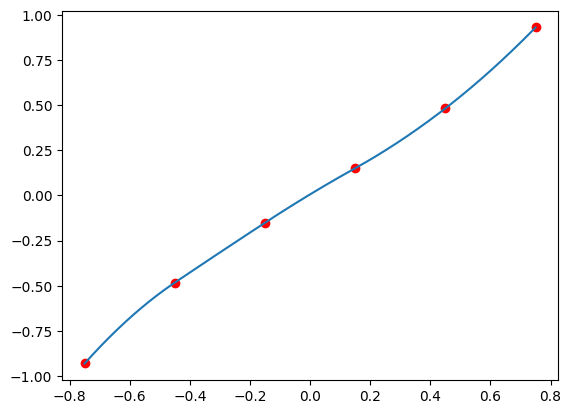

In [24]:
plt.plot(x_vals, y_vals, label="Сплайн")
plt.scatter(x_values, y_values, color='red', label="Узлы")
plt.show()